In [112]:
import mlxtend
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')

from matplotlib import rc, font_manager
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 폰트 관련 용도
%config InlineBackend.figure_format = 'retina'



# 디렉토리 및 파일 이름에 맞추어 변경
font_location = '/usr/share/fonts/truetype/humor-sans/Humor-Sans.ttf'#윈도우안에있는 폰트파일주소.
font_name = fm.FontProperties(fname=font_location).get_name()
rc('font', family=font_name)

In [113]:
from mlxtend.preprocessing import TransactionEncoder

In [114]:
data = np.array([
    ['우유', '기저귀', '쥬스', '감자'],
    ['양상추', '기저귀', '맥주', '고구마'],
    ['우유', '양상추', '기저귀', '쥬스'],
    ['양상추', '맥주', '물', '쿠키']
])

In [115]:
te = TransactionEncoder()

In [116]:
te_ary = te.fit(data).transform(data)
print(te_ary)

[[ True False  True False False False  True  True False]
 [False  True  True  True False  True False False False]
 [False False  True False False  True  True  True False]
 [False False False  True  True  True False False  True]]


In [117]:
df = pd.DataFrame(te_ary, columns=te.columns_)

In [118]:
df

,감자,고구마,기저귀,맥주,물,양상추,우유,쥬스,쿠키
0,True,False,True,False,False,False,True,True,False
1,False,True,True,True,False,True,False,False,False
2,False,False,True,False,False,True,True,True,False
3,False,False,False,True,True,True,False,False,True


In [119]:
from mlxtend.frequent_patterns import apriori

In [120]:
result = apriori(df, min_support=0.5, use_colnames=True)
result

,support,itemsets
0,0.75,(기저귀)
1,0.50,(맥주)
2,0.75,(양상추)
3,0.50,(우유)
4,0.50,(쥬스)
5,0.50,"(양상추, 기저귀)"
6,0.50,"(기저귀, 우유)"
7,0.50,"(기저귀, 쥬스)"
8,0.50,"(양상추, 맥주)"
9,0.50,"(쥬스, 우유)"


In [121]:
## 쥬스+우유를 함께 산 사람에게 추천을 해준다고 한다면,
## 맥주보다는 기저귀를 추천해야함.
## 지지도 기반으로 판단!

In [122]:
apriori(df, min_support=0.7, use_colnames=True)

,support,itemsets
0,0.75,(기저귀)
1,0.75,(양상추)


In [123]:
type(result) #result = apriori(df, min_support=0.5, use_colnames=True)

pandas.core.frame.DataFrame

In [124]:
# result에서 마지막 itemsets컬럼값 추출
## 쥬스, 우유와 함께 추천하면 좋을 item은??

In [125]:
choice = result.iloc[10, :]
choice

,10
support,0.5
itemsets,"(기저귀, 쥬스, 우유)"


In [126]:
items = choice['itemsets']
items

frozenset({np.str_('기저귀'), np.str_('우유'), np.str_('쥬스')})

In [127]:
list(items)[2]

np.str_('우유')

In [128]:
## one-hot인코딩 방식의 테이블이 필요!!!
## 실제로는 물건의 개수가 아주 많음.
## item 수 => 1조: 38441개의 여행지, 2조: 388개의 물건
## user 수 => 1조: 70000명, 2조: 800명
## 1조: 70000 * 38441, 2조: 800 * 388
## 1조인 경우 한 사람이 간 곳이 10개라고 한다면, 나머지는 0
## ==> 0이 2차원 데이터: 희소행렬(sparse matrix)
## TF-IDF, CounterVectorizor, TransactionEncoder

In [129]:
# !pip install gensim

In [130]:
from gensim.models import Word2Vec

In [131]:
## 자연어에서 특정한 단어(word)를 중심으로 앞 뒤의 단어를 유추(예측, 추론)할 때 사용됨.

In [132]:
doc = [
    'you say goodbye and I say hello',
    'i say happy or he said white',
    'we say unhappy and angry black'
]

In [133]:
doc2 = [
    '나는 굿바이라고 했고, 너는 헬로우라고 했어.',
    '나는 기쁘다고 했고, 너는 하얗게 슬프다고 했어.',
    '우리는 행복하지 않고, 블랙으로 슬퍼'
]

In [134]:
##문장을 토큰으로 끊어내자.
sentences = [sentence.split(' ') for sentence in doc]
sentences

[['you', 'say', 'goodbye', 'and', 'I', 'say', 'hello'],
 ['i', 'say', 'happy', 'or', 'he', 'said', 'white'],
 ['we', 'say', 'unhappy', 'and', 'angry', 'black']]

In [135]:
sentences2 = [sentence.split(' ') for sentence in doc2]
sentences2

[['나는', '굿바이라고', '했고,', '너는', '헬로우라고', '했어.'],
 ['나는', '기쁘다고', '했고,', '너는', '하얗게', '슬프다고', '했어.'],
 ['우리는', '행복하지', '않고,', '블랙으로', '슬퍼']]

In [136]:
model = Word2Vec(window=1, min_count=1) ##특정한 단어의 앞뒤 단어를 유추가능.
## window: 유추하는 계산을 할 때 특정한 단어의 앞뒤 몇개를 가지고 계산을 할지의 단위
## min_count: 특정한 패턴의 출현 횟수

In [137]:
model2 = Word2Vec(window=1, min_count=1)
model2.build_vocab(sentences2)

In [138]:
model.build_vocab(sentences) #영문문장을 가지고 계산을 함.

In [139]:
## 특정한 단어를 주고 앞뒤 단어를 추론해보자.
model.wv.most_similar('say') ##비지도!!

[('or', 0.21617142856121063),
 ('hello', 0.0931011214852333),
 ('said', 0.09291722625494003),
 ('i', 0.07963486760854721),
 ('happy', 0.06285078823566437),
 ('you', 0.05433367192745209),
 ('he', 0.0270574688911438),
 ('white', 0.016134677454829216),
 ('and', -0.01083916611969471),
 ('unhappy', -0.027750369161367416)]

In [140]:
model.wv.most_similar('or')

[('say', 0.21617141366004944),
 ('he', 0.044689226895570755),
 ('happy', 0.015025208704173565),
 ('you', 0.010695204138755798),
 ('white', 0.0019510718993842602),
 ('black', -0.03284316137433052),
 ('goodbye', -0.04552275687456131),
 ('hello', -0.04568910226225853),
 ('i', -0.0742427185177803),
 ('said', -0.09326908737421036)]

In [141]:
## or단어 앞으로는 say가 나올 가능성이 제일 크고,
## or단어 뒤로는 black단어가 나올 가능성이 제일 큰 것을 알 수 있다.

In [142]:
model2.wv.most_similar('너는')

[('굿바이라고', 0.13725273311138153),
 ('나는', 0.06797593832015991),
 ('우리는', 0.03364057466387749),
 ('블랙으로', 0.009391162544488907),
 ('기쁘다고', 0.008315935730934143),
 ('슬퍼', 0.0045030261389911175),
 ('헬로우라고', -0.0036444442812353373),
 ('했어.', -0.010839177295565605),
 ('했고,', -0.023671656847000122),
 ('슬프다고', -0.09575343877077103)]

In [143]:
## '너는' 한글 단어 앞으로 나올 단어로는 굿바이라고를 추천,
## '너는' 한글 단어 뒤로 나올 단어로는 헬로우라고를 추천

In [144]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [145]:
tfidf = TfidfVectorizer(stop_words='english') #불용어처리가능한 ifidf객체 생성
##tfidf는 빈도수를 구하긴 하지만, 문서마다 자주 등장하는 문서는 각 문서를 구분할 단어로 사용하기는
##부적합하여 가중치를 낮추어 계산

In [146]:
tfidf_matrix = tfidf.fit_transform(doc)
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11 stored elements and shape (3, 9)>

In [147]:
## 3 x 9에서
## 3은 문서의 개수
## 9는 단어의 개수

In [148]:
tfidf_matrix.toarray()

array([[0.        , 0.        , 0.54270061, 0.        , 0.54270061,
        0.        , 0.64105545, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.54645401, 0.        ,
        0.54645401, 0.32274454, 0.        , 0.54645401],
       [0.54645401, 0.54645401, 0.        , 0.        , 0.        ,
        0.        , 0.32274454, 0.54645401, 0.        ]])

In [149]:
## 문서간의 유사도를 구해봅시다.!!
cosine_similarity(tfidf_matrix, tfidf_matrix)

array([[1.        , 0.20689715, 0.20689715],
       [0.20689715, 1.        , 0.10416404],
       [0.20689715, 0.10416404, 1.        ]])

In [150]:
## 행은 문서1, 문서2, 문서3
## 열도 문서1, 문서2, 문서3
## 문서1 + 문서2: 0.21
## 문서1 + 문서3: 0.21
## 문서2 + 문서3: 0.10
## 문서1과 2, 문서1과 3이 유사하다.
## 문서2와 3은 유사하지 않다.

In [151]:
## 1-1.모든 장바구니 유사도를 구해보세요.
## 1-2.유사도를 그래프로 비교해주세요.
## 2.장바구니 1번과 제일 유사도가 높은 장바구니를 찾아서
## 3.장바구니 1번에게 추천해주고 싶은 item을 추천해주세요.

In [152]:
cosine_similarity(df, df) #TransactionEncoding한 것으로 사용!

array([[1.  , 0.25, 0.75, 0.  ],
       [0.25, 1.  , 0.5 , 0.5 ],
       [0.75, 0.5 , 1.  , 0.25],
       [0.  , 0.5 , 0.25, 1.  ]])

In [153]:
## 장바구니 1번 + 2번 : 0.33
## 장바구니 1번 + 3번 : 0.87
## 장바구니 1번 + 4번 : 0.00
## 장바구니 2번 + 3번 : 0.58
## 장바구니 2번 + 4번 : 0.82
## 장바구니 3번 + 4번 : 0.35

In [154]:
basket_name = ['1번 + 2번', '1번 + 3번', '1번 + 4번', '2번 + 3번', '2번 + 3번', '3번 + 4번']
similar = [0.33, 0.87, 0.00, 0.58, 0.82, 0.35]

In [155]:
basket_df = pd.DataFrame(data = {'basket_name' : basket_name, 'similar' : similar})
basket_df

,basket_name,similar
0,1번 + 2번,0.33
1,1번 + 3번,0.87
2,1번 + 4번,0.00
3,2번 + 3번,0.58
4,2번 + 3번,0.82
5,3번 + 4번,0.35


In [156]:
colors = ['y','r', 'C2', '#e35f62', 'g', 'b']

<BarContainer object of 6 artists>

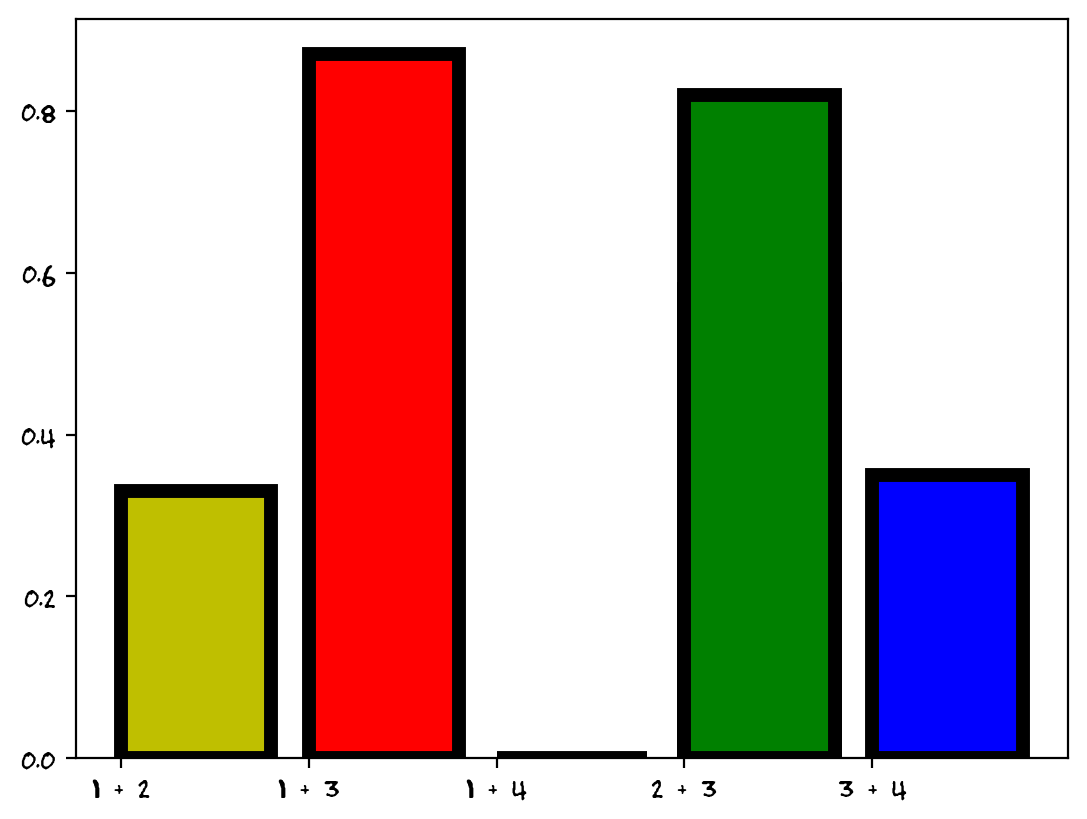

In [157]:
plt.bar(basket_df['basket_name'],
        basket_df['similar'],
        align='edge',
        edgecolor='black',
        linewidth=5,
        color=colors)

In [158]:
## TransactionEncoder : one-hot
## CounterVectorizer : count amount
## TF-IDFVectorizer : reduce most frequency weight

In [159]:
## 2.장바구니 1번과 제일 유사도가 높은 장바구니를 찾아서
## 3.장바구니 1번에게 추천해주고 싶은 item을 추천해주세요.

In [160]:
basket_cosine = cosine_similarity(df, df)
basket_cosine

array([[1.  , 0.25, 0.75, 0.  ],
       [0.25, 1.  , 0.5 , 0.5 ],
       [0.75, 0.5 , 1.  , 0.25],
       [0.  , 0.5 , 0.25, 1.  ]])

In [161]:
basket_cosine[0]

array([1.  , 0.25, 0.75, 0.  ])

In [162]:
basket_cosine[0][1:]

array([0.25, 0.75, 0.  ])

In [163]:
max_idx = np.argmax(basket_cosine[0][1:])
print('장바구니 번호: ', max_idx + 1 + 1, '번')

장바구니 번호:  3 번


In [164]:
data[0], data[2]

(array(['우유', '기저귀', '쥬스', '감자'], dtype='<U3'),
 array(['우유', '양상추', '기저귀', '쥬스'], dtype='<U3'))

In [165]:
## 3번 장바구니에서 1번 장바구니를 빼면 1번이 아직 사지 않은 물건들을 확인할 수 있음.
## 리스트는 '-'를 지원하지 않아, set(집합)으로 형변환함.
rec_item = set(data[2]) - set(data[0])
rec_item2 = rec_item.pop()
rec_item2

np.str_('양상추')

In [166]:
print('1번 장바구니 사용자에게 ' + str(rec_item2) + '를 추천합니다.')

1번 장바구니 사용자에게 양상추를 추천합니다.


In [167]:
item1 = 'https://upload.wikimedia.org/wikipedia/commons/thumb/2/20/Kropsla_herfst.jpg/250px-Kropsla_herfst.jpg'
item2 = 'https://m.seoulmilk.co.kr/mobile/product/product_view.sm?subname=P0&gubun=&nmNo=10000000000587&page=1'
item3 = 'https://cdn.oasis.co.kr:48581/product/81094/thumb/f22dc28a-41f1-4b4e-9cc8-6cd6181e178f.jpg'
item4 = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSuR4ZrfAJMpIh0ix9VokA9ATzYhhDjlZXcMA&s'
item0 = 'https://mediahub.seoul.go.kr/wp-content/uploads/2016/09/61a2981f41200ac8c513a3cbc0010efe.jpg'

In [168]:
def set_img(rec_item2):
    rec_item_img = item0
    if rec_item2 == '양상추':
        rec_item_img = item1
    elif rec_item2 == '우유':
        rec_item_img = item2
    elif rec_item2 == '기저귀':
        rec_item_img = item3
    else:
        rec_item_img = item4
    return rec_item_img
rec_item_img2 = set_img(rec_item2)
rec_item_img2

'https://upload.wikimedia.org/wikipedia/commons/thumb/2/20/Kropsla_herfst.jpg/250px-Kropsla_herfst.jpg'

In [169]:
from IPython.display import Image

In [170]:
basket_cosine[3] ##장바구니 4번의 유사 장바구니 찾기

array([0.  , 0.5 , 0.25, 1.  ])

In [171]:
basket_cosine[3][:-1]

array([0.  , 0.5 , 0.25])

In [172]:
max_idx = np.argmax(basket_cosine[3][:-1])
print('장바구니 번호: ', max_idx)

장바구니 번호:  1


In [173]:
data[3], data[1]

(array(['양상추', '맥주', '물', '쿠키'], dtype='<U3'),
 array(['양상추', '기저귀', '맥주', '고구마'], dtype='<U3'))

In [174]:
rec_item3 = set(data[1]) - set(data[3])
rec_item4 = rec_item3.pop()
rec_item4

np.str_('기저귀')

In [175]:
rec_item_img2 = set_img(rec_item4)
rec_item_img2

'https://cdn.oasis.co.kr:48581/product/81094/thumb/f22dc28a-41f1-4b4e-9cc8-6cd6181e178f.jpg'

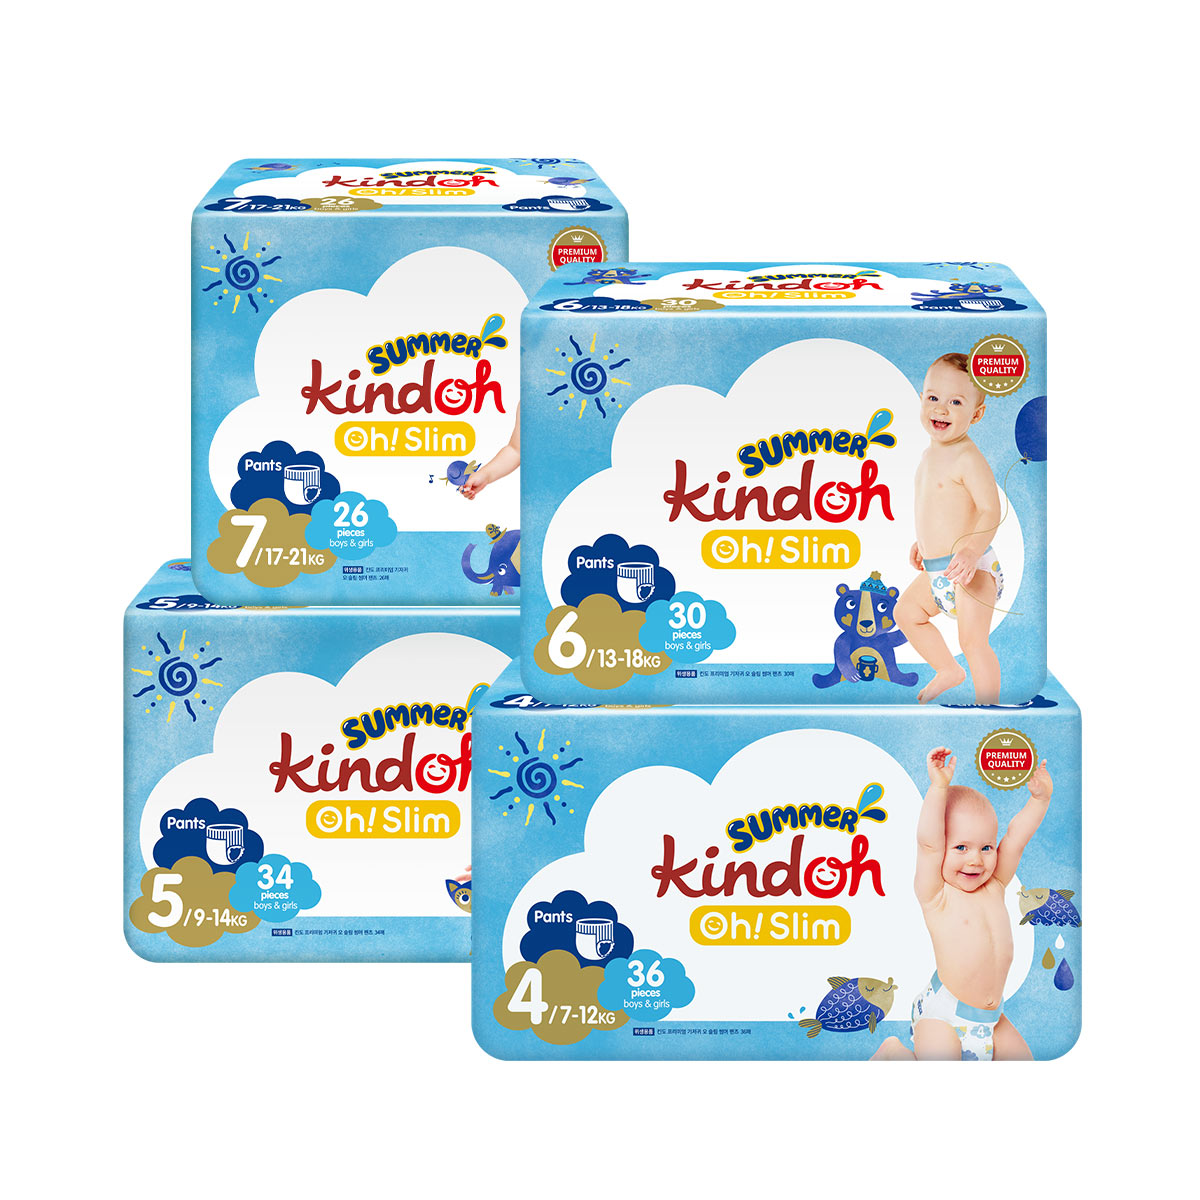

In [176]:
Image(rec_item_img2)